<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</h1></center>
<h2>Actividad 1. Laboratorio: Árboles de decisión, reglas y ensemble learning</h2>

Nombres y Apellidos: Getulio Cesar De Leon Fernandez  <br>
Fecha: 16/03/2026 <br>
Matricula: 5882984 - 964830

## 1. Importación de librerías necesarias

In [58]:
# Librería para manipulación y carga de datos (importación del dataset en formato CSV)
import pandas as pd

# Librería para cálculo numérico y manejo de arrays multidimensionales
import numpy as np

# Librerías de visualización gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento: codificación ordinal de atributos categóricos
from sklearn.preprocessing import OrdinalEncoder, label_binarize

# División del dataset en entrenamiento y test con estratificación
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Modelo 1: árbol de decisión CART (implementación scikit-learn)
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Modelo 2: Random Forest (método de aprendizaje integrado - Bagging con árboles)
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación de clasificadores
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


El entorno de desarrollo utiliza las siguientes librerías:

**`pandas`** proporciona estructuras de datos tabulares (`DataFrame`) para la 
carga, inspección y manipulación del dataset en formato CSV.

**`numpy`** ofrece soporte para operaciones numéricas sobre arrays 
multidimensionales, utilizado internamente por scikit-learn y en el cálculo 
de umbrales y probabilidades.

**`matplotlib`** y **`seaborn`** son las librerías de visualización gráfica 
utilizadas para generar las distribuciones de clases, matrices de confusión, 
curvas ROC, distribuciones de probabilidad por umbral y gráficas comparativas 
de métricas.

**`sklearn.preprocessing`** aporta `OrdinalEncoder` para la codificación 
ordinal de los atributos categóricos de entrada, y `label_binarize` para la 
binarización *one-vs-rest* requerida en el análisis de umbrales y curvas ROC.

**`sklearn.model_selection`** proporciona `train_test_split` para la división 
estratificada del dataset en entrenamiento y test, y `cross_val_score` junto 
con `StratifiedKFold` para la validación cruzada de **10 pliegues** con 
preservación de proporciones de clase.

**`sklearn.tree`** contiene `DecisionTreeClassifier`, la implementación 
optimizada del algoritmo **CART**, y `plot_tree` para la visualización del 
árbol inducido.

**`sklearn.ensemble`** contiene `RandomForestClassifier`, la implementación 
del método de **aprendizaje integrado** basado en **Bagging** con árboles de 
decisión.

**`sklearn.metrics`** agrupa las métricas de evaluación: `accuracy_score`, 
`classification_report`, `confusion_matrix` y `ConfusionMatrixDisplay` para 
el análisis de errores por clase; `precision_score`, `recall_score` y 
`f1_score` para las métricas macro; y `roc_curve`, `auc` y `roc_auc_score` 
para el análisis de curvas ROC y áreas bajo la curva.

## 2. Cargar el Dataset

In [59]:
try:
    df = pd.read_csv('Laboratorio_dataset_car.csv', sep=';')
    print('Dataset cargado desde archivo local.')
except (Exception):
    url = 'https://raw.githubusercontent.com/deleongetulio/Getulio_Maestria_Ciencia_De_Datos_Unir/refs/heads/main/Laboratorio_dataset_car.csv'
    df = pd.read_csv(url, sep=';')
    print('Dataset cargado desde repositorio remoto.')
    
print(f'Dimensiones: {df.shape[0]} instancias × {df.shape[1]} atributos')
df.head(10)

Dataset cargado desde archivo local.
Dimensiones: 1750 instancias × 7 atributos


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,low,unacc
8,vhigh,vhigh,2,2,big,med,unacc
9,vhigh,vhigh,2,2,big,high,unacc


El dataset se carga prioritariamente desde el directorio de ejecución; si el 
archivo no se encuentra, el código recurre automáticamente a un repositorio 
público como fallback, garantizando reproducibilidad sin depender de rutas 
absolutas. El separador de campos es el punto y coma (`;`), tal como se 
especifica en la descripción original del dataset. Se verifican las dimensiones 
del dataset cargado y se muestran las primeras **10 instancias** para confirmar 
la carga correcta y revisar la estructura de los datos.

## 3. Descripción del problema

Se trata de un problema de **clasificación supervisada multiclase**. En este tipo de aprendizaje, el programa aprende de una experiencia E —el conjunto 
de instancias de entrenamiento ya clasificadas— con el fin de mejorar su rendimiento 
P en la tarea T de predecir la clase de nuevas instancias (Tema 1, *Ideas clave*, UNIR). El material del curso 
señala que los árboles de decisión han sido aplicados con éxito a problemas del mundo 
real, *«resultando muy adecuados para resolver problemas de clasificación, esto es, 
cuando la tarea consiste en clasificar ejemplos dentro de un conjunto discreto de 
posibles categorías»* (Tema 3, *Ideas clave*, UNIR), condición que se cumple 
directamente en este problema.

La variable objetivo `class` representa la **aceptabilidad** (evaluación general) de un automóvil con 
cuatro valores discretos: `unacc` (inaceptable), `acc` (aceptable), `good` (bueno) 
y `vgood` (muy bueno). Los atributos de entrada son seis variables categóricas 
ordinales: precio de compra (`Buying`), coste de mantenimiento (`Maintenance`), 
número de puertas (`Doors`), capacidad de personas (`Person`), tamaño del maletero 
(`lug_boot`) y nivel de seguridad (`safety`). La naturaleza ordinal de estos 
atributos los hace directamente compatibles con **CART** y **Random Forest** sin 
requerir normalización.

El modelo aprendido tiene aplicación directa en plataformas de venta de automóviles, 
aseguradoras y sistemas de apoyo a la decisión de compra, donde clasificar 
automáticamente la aceptabilidad de un vehículo a partir de sus características 
aporta valor sin necesidad de conocimiento previo del dominio.

## 4. Caracterización del Dataset "Análisis Exploratorio de Datos" (EDA)

### 4.1 Estructura y atributos del dataset 

In [60]:
# ───  4.1 Estructura y atributos del dataset ────────────────────────────────────────
# Se muestran las características básicas del conjunto de datos de entrenamiento
# siguiendo la estructura de descripción recomendada en el enunciado de la actividad.

feature_cols  = ['Buying', 'Maintenance', 'Doors', 'Person', 'lug_boot', 'safety']
target_col    = 'class'
orden_clases  = ['unacc', 'acc', 'good', 'vgood']

print('=' * 55)
print('  CARACTERIZACIÓN DEL DATASET')
print('=' * 55)
print(f'Número total de instancias     : {df.shape[0]}')
print(f'Número de atributos de entrada (las columnas que el modelo usa para predecir): {len(feature_cols)}')
print(f'Número de clases (variable obj) (los posibles resultados que el modelo puede predecir.): {df[target_col].nunique()}')
print()

# Tipos de datos de cada atributo
print('── Atributos de entrada y tipo de valor ──')
descripciones = {
    'Buying'      : 'Precio de compra del vehículo',
    'Maintenance' : 'Coste de mantenimiento',
    'Doors'       : 'Número de puertas',
    'Person'      : 'Capacidad de personas',
    'lug_boot'    : 'Tamaño del maletero',
    'safety'      : 'Nivel de seguridad'
}
for col in feature_cols:
    print(f'  {col:15s}: {descripciones[col]:35s} | Valores Ordinales: {list(df[col].unique())}')

print()
print('── Distribución de instancias por clase ──')
conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True) * 100
tabla_clases = pd.DataFrame({
    'Instancias'    : conteo,
    'Porcentaje (%)': porcentaje.round(2)
})
display(tabla_clases)

print()
print('── Valores de atributo desconocidos ──')
nulos = df.isnull().sum()
print(nulos)
print(f'\nTotal de valores nulos: {nulos.sum()} → No existen valores desconocidos.')

  CARACTERIZACIÓN DEL DATASET
Número total de instancias     : 1750
Número de atributos de entrada (las columnas que el modelo usa para predecir): 6
Número de clases (variable obj) (los posibles resultados que el modelo puede predecir.): 4

── Atributos de entrada y tipo de valor ──
  Buying         : Precio de compra del vehículo       | Valores Ordinales: ['vhigh', 'high', 'med', 'low']
  Maintenance    : Coste de mantenimiento              | Valores Ordinales: ['vhigh', 'high', 'med', 'low']
  Doors          : Número de puertas                   | Valores Ordinales: ['2', '3', '4', '5more']
  Person         : Capacidad de personas               | Valores Ordinales: ['2', '4', 'more']
  lug_boot       : Tamaño del maletero                 | Valores Ordinales: ['small', 'med', 'big']
  safety         : Nivel de seguridad                  | Valores Ordinales: ['low', 'med', 'high']

── Distribución de instancias por clase ──


,Instancias,Porcentaje (%)
class,,
unacc,1215,69.43
acc,390,22.29
good,75,4.29
vgood,70,4.00



── Valores de atributo desconocidos ──
Buying         0
Maintenance    0
Doors          0
Person         0
lug_boot       0
safety         0
class          0
dtype: int64

Total de valores nulos: 0 → No existen valores desconocidos.


El dataset contiene **1.750 instancias** descritas mediante **6 atributos de entrada** 
de naturaleza **categórica ordinal** y una variable objetivo con **4 clases discretas**. 
Ningún atributo presenta valores desconocidos, por lo que no fue necesario aplicar 
técnicas de imputación. Los atributos `Buying` y `Maintenance` comparten la misma 
escala ordinal de 4 niveles (`low` → `vhigh`), mientras que `Doors`, `Person`, 
`lug_boot` y `safety` presentan entre 3 y 4 categorías propias de su dominio. 
La ausencia de atributos continuos hace que el dataset sea directamente compatible 
con el algoritmo **CART** sin transformaciones adicionales más allá de la 
**codificación ordinal**. De igual manera, **Random Forest** hereda esta 
compatibilidad al estar construido sobre múltiples árboles CART, por lo que ambos 
modelos operan sobre la misma representación numérica sin requerir normalización 
ni estandarización.

### 4.2 Distribución de la clase objetivo 

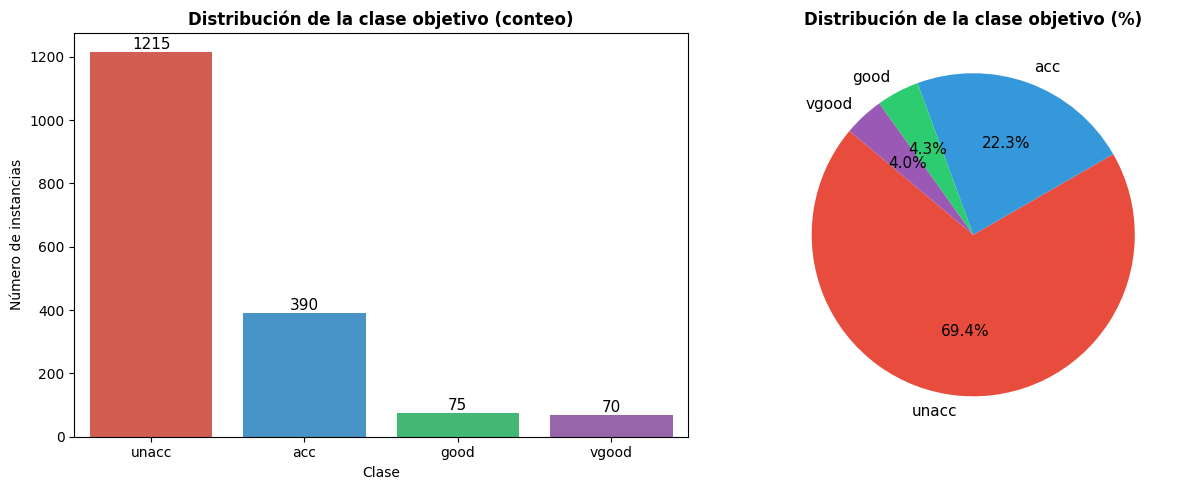

In [61]:
# ─── Visualización 1: Distribución de la clase objetivo ─────────────────────
# Se analiza el balance de clases, aspecto crítico para la evaluación del modelo.
# El material del curso advierte que el sobreajuste puede ocurrir cuando los datos
# de entrenamiento no son suficientemente representativos de todas las clases.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# Gráfico de barras: conteo por clase
sns.countplot(data=df, x=target_col, order=orden_clases, palette=colores, ax=axes[0])
axes[0].set_title('Distribución de la clase objetivo (conteo)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de instancias')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Gráfico de pastel: proporción porcentual
axes[1].pie(
    [conteo[c] for c in orden_clases],
    labels=orden_clases, colors=colores,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11}
)
axes[1].set_title('Distribución de la clase objetivo (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()

La variable objetivo presenta un marcado **desbalance de clases**: `unacc` concentra 
el **69.4%** de las instancias (1.215), `acc` representa el **22.3%** (390), mientras 
que `good` y `vgood` juntas apenas alcanzan el **8.3%** (75 y 70 instancias 
respectivamente). Este desbalance es el principal desafío de modelación, ya que sin 
corrección cualquier clasificador tendería a predecir sistemáticamente la clase 
mayoritaria, obteniendo alta exactitud global pero rendimiento muy bajo en las clases 
minoritarias. Para compensarlo, ambos modelos utilizan `class_weight='balanced'`, 
que asigna pesos inversamente proporcionales a la frecuencia de cada clase durante 
el entrenamiento. Adicionalmente, la partición train/test se realizó con 
**estratificación** para preservar estas proporciones en ambos conjuntos.

### 4.3 Frecuencia de categorías por atributo de entrada

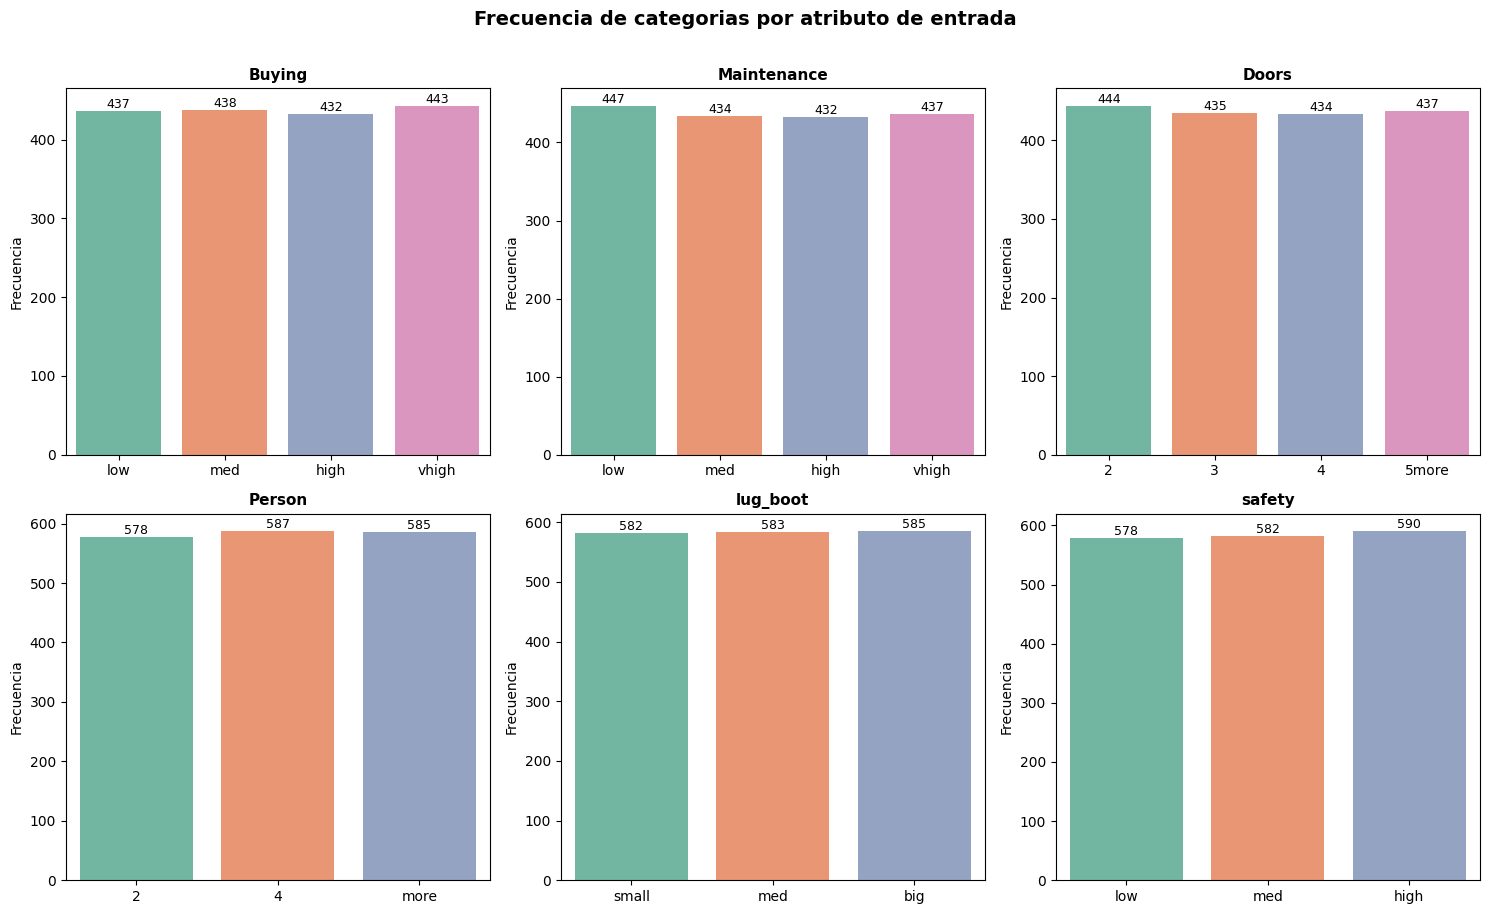

In [62]:
# ─── Visualización 2: Frecuencia de categorías por atributo de entrada ───────
# Los árboles de decisión trabajan con atributos discretos (nominales u ordinales).
# Esta visualización confirma que todos los atributos de entrada son categóricos,
# lo que los hace idóneos para el algoritmo CART implementado en scikit-learn.

ordenes_graficas = {
    'Buying'      : ['low', 'med', 'high', 'vhigh'],
    'Maintenance' : ['low', 'med', 'high', 'vhigh'],
    'Doors'       : ['2', '3', '4', '5more'],
    'Person'      : ['2', '4', 'more'],
    'lug_boot'    : ['small', 'med', 'big'],
    'safety'      : ['low', 'med', 'high'],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    orden = ordenes_graficas[col]
    vc = df[col].value_counts().reindex(orden)
    sns.barplot(x=vc.index, y=vc.values, ax=axes[i], palette='Set2', order=orden)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

plt.suptitle('Frecuencia de categorias por atributo de entrada', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_frecuencia_atributos.png', dpi=120, bbox_inches='tight')
plt.show()

Todos los atributos de entrada presentan una distribución prácticamente **uniforme** 
entre sus categorías. `Buying`, `Maintenance` y `Doors` muestran frecuencias entre 
432 y 447 instancias por categoría, con una variación máxima de 15 instancias. 
`Person`, `lug_boot` y `safety` presentan distribuciones igualmente equilibradas, 
con frecuencias entre 578 y 590 instancias por categoría dado que tienen 3 niveles 
en lugar de 4.

Esta uniformidad es una característica relevante del dataset: al no existir 
categorías dominantes en los atributos de entrada, el método de selección basado 
en el **índice Gini** no estará artificialmente sesgado hacia ningún atributo por 
razones de frecuencia. La discriminación entre clases dependerá exclusivamente 
de la relación real entre cada atributo y la variable objetivo.

### 4.4 Relación entre todos los atributos y la clase objetivo

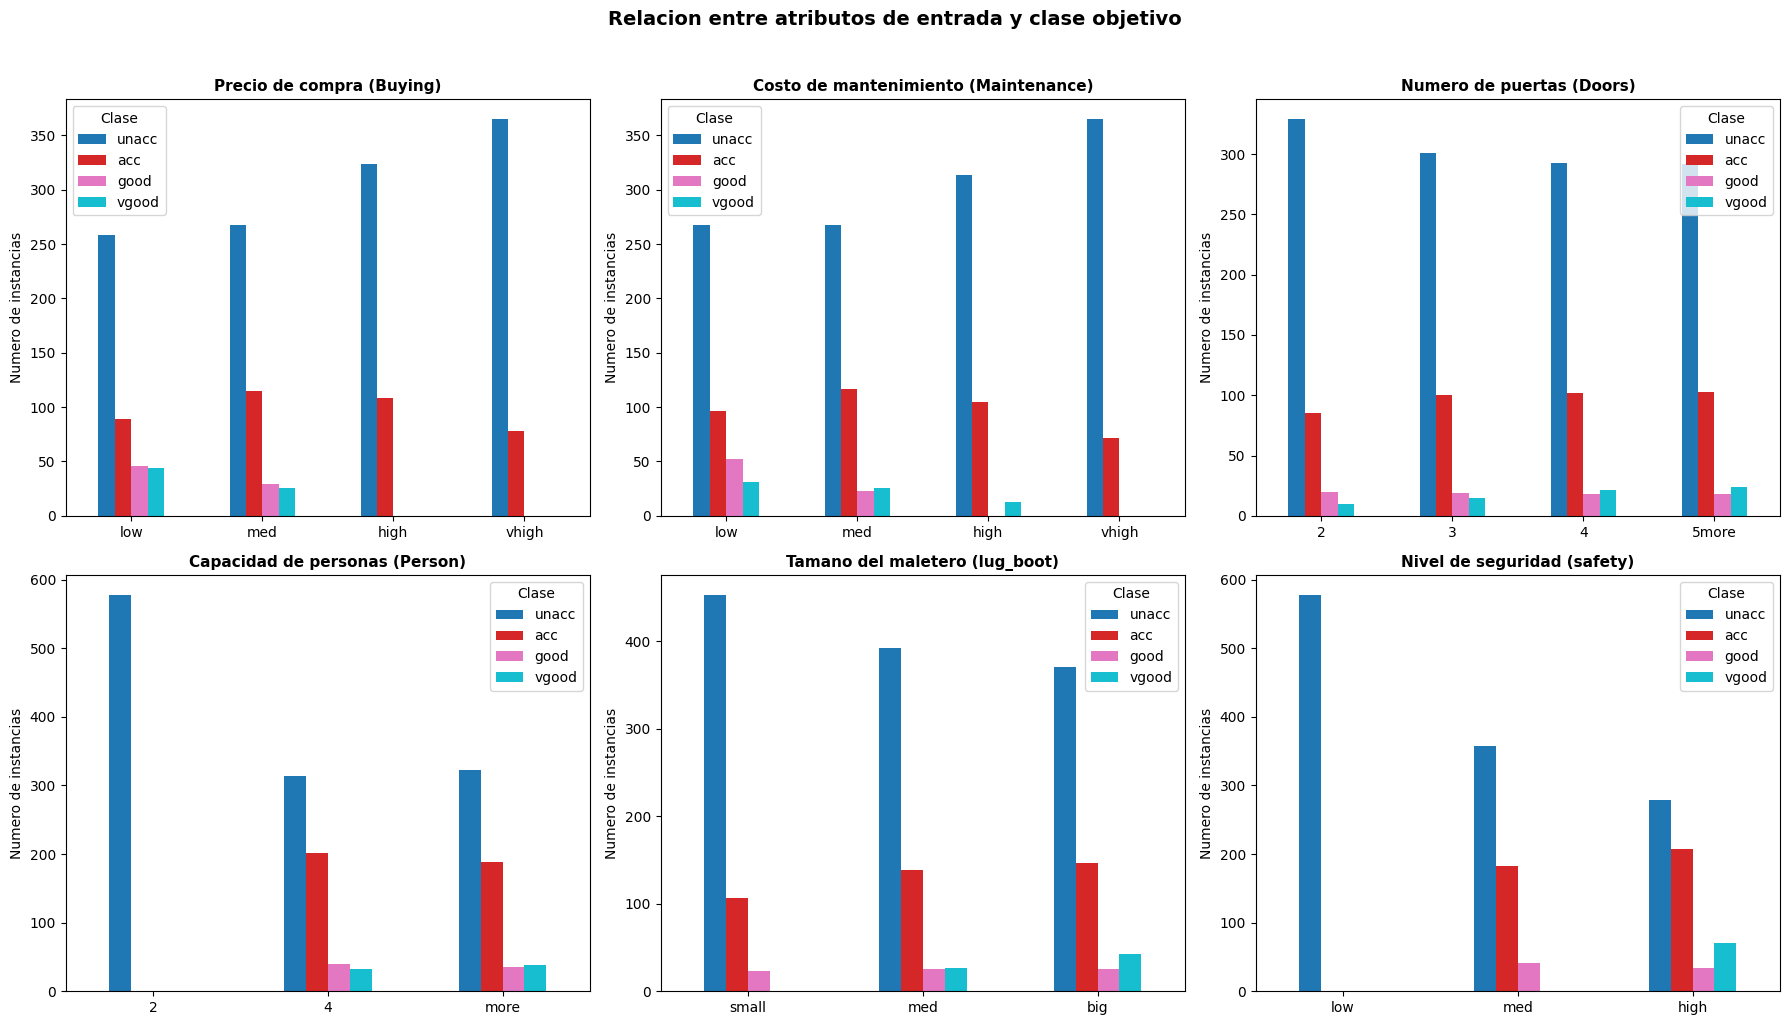

In [63]:
# ─── Visualización 3: Relación entre todos los atributos y la clase objetivo ─
# Se grafican los 6 atributos ordenados de menor a mayor valor semántico
# para anticipar el poder discriminativo de cada uno antes del modelado.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

ordenes_graficas = {
    'Buying'      : ['low', 'med', 'high', 'vhigh'],
    'Maintenance' : ['low', 'med', 'high', 'vhigh'],
    'Doors'       : ['2', '3', '4', '5more'],
    'Person'      : ['2', '4', 'more'],
    'lug_boot'    : ['small', 'med', 'big'],
    'safety'      : ['low', 'med', 'high'],
}

titulos = {
    'Buying'      : 'Precio de compra (Buying)',
    'Maintenance' : 'Costo de mantenimiento (Maintenance)',
    'Doors'       : 'Numero de puertas (Doors)',
    'Person'      : 'Capacidad de personas (Person)',
    'lug_boot'    : 'Tamano del maletero (lug_boot)',
    'safety'      : 'Nivel de seguridad (safety)',
}

for i, col in enumerate(feature_cols):
    ct = pd.crosstab(df[col], df[target_col])
    ct.loc[ordenes_graficas[col], orden_clases].plot(
        kind='bar', ax=axes[i], colormap='tab10', rot=0
    )
    axes[i].set_title(titulos[col], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Numero de instancias')
    axes[i].legend(title='Clase')

plt.suptitle('Relacion entre atributos de entrada y clase objetivo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_atributos_vs_clase.png', dpi=120, bbox_inches='tight')
plt.show()

El análisis cruzado revela patrones discriminativos claros en varios atributos. 
`Buying` y `Maintenance` muestran una **relación positiva con `unacc`**: a mayor 
precio de compra o coste de mantenimiento, mayor concentración de vehículos 
inaceptables, mientras que las clases `good` y `vgood` prácticamente desaparecen 
en los niveles `vhigh`. `Doors` no muestra un patrón discriminativo relevante: 
la proporción entre clases es similar en todos sus niveles, lo que anticipa su 
**baja importancia** en el modelo.

`Person` es el atributo más determinante: con capacidad de **2 personas** el 100% 
de las instancias pertenece a `unacc`, sin excepción. De igual forma, con 
`safety=low` ninguna instancia pertenece a `good` o `vgood`. En ambos casos, a 
medida que el valor del atributo aumenta en la escala ordinal, las clases positivas 
comienzan a aparecer progresivamente. `lug_boot` presenta un patrón más moderado, 
con una ligera mejora en las clases positivas conforme aumenta el tamaño del maletero.

Estos patrones confirman que `Person` y `safety` son los atributos con **mayor poder 
discriminativo** del dataset, ambos capaces de producir subgrupos perfectamente puros 
(**Gini=0.0**) para la clase `unacc`, lo que los convierte en candidatos directos 
para los primeros nodos del árbol de decisión del modelo **CART**.

### 4.5  Resumen de hallazgos del Análisis Exploratorio de Datos (EDA)



El dataset contiene **1.750 instancias sin valores de atributo desconocidos**, con seis 
atributos de entrada de naturaleza categórica ordinal, lo que lo hace idóneo para el 
aprendizaje mediante árboles de decisión. La ausencia de atributos continuos garantiza 
compatibilidad directa con **CART** y **Random Forest** sin requerir normalización ni 
estandarización. Todos los atributos presentan una distribución uniforme entre sus 
categorías, lo que garantiza que ningún atributo domine artificialmente la selección 
del nodo raíz por razones de frecuencia.

La distribución de la clase objetivo es marcadamente **desbalanceada**: la clase `unacc` 
representa el 69.4% de las instancias, mientras que `good` y `vgood` juntas apenas 
alcanzan el 8.3%. Este desbalance es un factor de **bias inductivo** que el clasificador 
debe compensar para evitar que la hipótesis aprendida favorezca la clase mayoritaria.

Del análisis cruzado se observa que los atributos `Person` y `safety` presentan el mayor 
poder discriminativo del dataset. Ningún vehículo con `Person=2` ni con `safety=low` 
alcanza una clasificación positiva (`good` o `vgood`), produciendo subgrupos 
perfectamente puros (Gini=0.0) clasificados como `unacc`. El algoritmo CART 
seleccionó `Person` como nodo raíz al producir la mayor reducción de impureza global, 
con `safety` como segunda división, resultado consistente con lo anticipado en el EDA.

## 5. Preprocesamiento del dataset

In [64]:
# ─── Codificación ordinal de atributos categóricos ───────────────────────────
# Scikit-learn implementa una versión optimizada del algoritmo CART que requiere
# que los atributos de entrada sean numéricos. Se aplica OrdinalEncoder respetando
# el orden semántico de cada atributo categórico ordinal, de menor a mayor valor.
# Esto preserva la información de orden implícita en los datos (ej: low < med < high < vhigh).

ordenes = {
    'Buying'      : ['low', 'med', 'high', 'vhigh'],
    'Maintenance' : ['low', 'med', 'high', 'vhigh'],
    'Doors'       : ['2', '3', '4', '5more'],
    'Person'      : ['2', '4', 'more'],
    'lug_boot'    : ['small', 'med', 'big'],
    'safety'      : ['low', 'med', 'high'],
}

df_enc = df.copy()

# Codificación de atributos de entrada
enc = OrdinalEncoder(categories=[ordenes[c] for c in feature_cols])
df_enc[feature_cols] = enc.fit_transform(df_enc[feature_cols])

# Codificación de la variable objetivo respetando orden ordinal
# Se usa un mapeo manual para preservar el orden correcto:
# unacc=0, acc=1, good=2, vgood=3
orden_clases  = ['unacc', 'acc', 'good', 'vgood']
mapeo_clases  = {clase: i for i, clase in enumerate(orden_clases)}
df_enc[target_col] = df_enc[target_col].map(mapeo_clases)

print('Mapeo de clases:', mapeo_clases)
print()
print('Primeras instancias tras codificación ordinal:')
display(df_enc.head())

Mapeo de clases: {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}

Primeras instancias tras codificación ordinal:


,Buying,Maintenance,Doors,Person,lug_boot,safety,class
0,3.0,3.0,0.0,0.0,0.0,0.0,0
1,3.0,3.0,0.0,0.0,0.0,1.0,0
2,3.0,3.0,0.0,0.0,0.0,2.0,0
3,3.0,3.0,0.0,0.0,1.0,0.0,0
4,3.0,3.0,0.0,0.0,1.0,1.0,0


Dado que todos los atributos son de naturaleza **categórica ordinal**, el 
preprocesamiento consistió en convertir cada categoría a su representación 
numérica respetando el orden semántico de la escala. Para los atributos de 
entrada se aplicó `OrdinalEncoder` con el orden explícito de cada atributo 
(`low=0`, `med=1`, `high=2`, `vhigh=3` para `Buying` y `Maintenance`, por 
ejemplo), garantizando que la codificación numérica preserve la relación 
ordinal original.

Para la variable objetivo `class` se utilizó un **mapeo manual** 
(`unacc=0`, `acc=1`, `good=2`, `vgood=3`) en lugar de `LabelEncoder`, ya 
que este último ordena alfabéticamente y rompería el orden ordinal de la 
escala de aceptabilidad. Tras el preprocesamiento, todos los atributos toman 
valores enteros en el rango correspondiente a su número de categorías, como 
se observa en las primeras instancias codificadas: `Buying=3.0` y 
`Maintenance=3.0` corresponden a `vhigh`, mientras que `Person=0.0` y 
`safety=0.0` corresponden a los niveles más bajos de sus respectivas escalas.

No fue necesario aplicar técnicas de imputación, normalización ni 
estandarización, ya que el dataset no presenta **valores desconocidos** y 
los algoritmos **CART** y **Random Forest** no requieren que los atributos 
estén en la misma escala numérica para operar correctamente.

## 6. División del dataset en datos de entrenamiento y datos de test

In [65]:
# ─── Separación features / target ───────────────────────────────────────────
X = df_enc[feature_cols]
y = df_enc[target_col]

# Estrategia de evaluación: hold-out estratificado 80/20
# El material del curso indica que «se suele utilizar un 80% de los datos para
# entrenar los algoritmos y un 20% para hacer los test de predicción».
# La estratificación garantiza que la proporción de instancias de cada clase
# se mantiene en ambos conjuntos, esencial dado el fuerte desbalance del dataset.
# Adicionalmente, se aplicará validación cruzada estratificada de 10 iteraciones
# (k-fold con k=10) para estimar la precisión real de generalización del modelo,
# tal como recomienda el material del Tema 3.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserva la distribución de clases en ambas particiones
)

print(f'Instancias de entrenamiento : {X_train.shape[0]} (80%)')
print(f'Instancias de test          : {X_test.shape[0]}  (20%)')
print()
print('Distribución de clases en entrenamiento:')
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print('Distribución de clases en test:')
print((y_test.value_counts(normalize=True) * 100).round(2))


Instancias de entrenamiento : 1400 (80%)
Instancias de test          : 350  (20%)

Distribución de clases en entrenamiento:
class
0    69.43
1    22.29
2     4.29
3     4.00
Name: proportion, dtype: float64

Distribución de clases en test:
class
0    69.43
1    22.29
2     4.29
3     4.00
Name: proportion, dtype: float64


El dataset se dividió en una proporción **80/20**: **1.400 instancias** para 
entrenamiento y **350 instancias** para test. Dado el marcado desbalance de 
clases, la partición se realizó con `stratify=y`, lo que garantiza que la 
distribución de clases se preserve de forma idéntica en ambos conjuntos: 
`unacc=69.43%`, `acc=22.29%`, `good=4.29%` y `vgood=4.00%`. Sin 
estratificación, una partición aleatoria simple podría subrepresentar las 
clases minoritarias `good` y `vgood` en el conjunto de test, comprometiendo 
la validez de las métricas de evaluación.

## 7. Selección, configuración y entrenamiento de los modelos

### 7.1 Justificación de los modelos seleccionados

Se seleccionan dos algoritmos que representan dos aproximaciones diferenciadas 
dentro del **aprendizaje inductivo supervisado**: un modelo base interpretable 
y un modelo de **aprendizaje integrado** (*ensemble learning*).

**Árbol de Decisión (CART)** es un algoritmo de **clasificación supervisada** 
que construye una estructura jerárquica de decisiones binarias utilizando el 
**índice Gini** como criterio de selección de atributos. Su selección se justifica 
por tres razones: primero, los atributos del dataset son categóricos ordinales, 
tipo de dato con el que **CART** trabaja de forma nativa sin requerir transformaciones 
adicionales. Segundo, la naturaleza interpretable del árbol permite traducir el 
modelo directamente a **reglas de clasificación** legibles, lo que facilita la 
auditoría del sistema en un contexto de recomendación de vehículos. Tercero, 
actúa como modelo base de referencia (*baseline*) frente al que evaluar la 
ganancia del modelo de **aprendizaje integrado**.

**Random Forest (Bagging)** extiende el árbol individual mediante la construcción 
de un conjunto de hipótesis parciales en paralelo. Como describe el material del 
curso (Tema 3, *Ideas clave*, UNIR), en los métodos **Bagging** cada algoritmo 
se entrena con un subconjunto aleatorio **bootstrap** de los datos, y las 
predicciones se agregan mediante votación. Su selección se justifica porque el 
dataset presenta un **desbalance de clases** pronunciado (`unacc`=69.4%), 
condición en la que los modelos individuales tienden al **sobreajuste** sobre 
la clase mayoritaria. La diversidad de hipótesis del **Random Forest** reduce 
este riesgo al promediar múltiples árboles entrenados sobre subconjuntos 
distintos, mejorando la generalización en las clases minoritarias `good` y 
`vgood`.

La selección conjunta de ambos modelos permite además un análisis comparativo 
directo entre **interpretabilidad** y **rendimiento predictivo**, uno de los 
dilemas fundamentales del aprendizaje automático supervisado.

### 7.2 Árbol de Decisión (CART)

**Scikit-learn** implementa una versión optimizada del algoritmo **CART** 
(*Classification and Regression Trees*), que utiliza el **índice Gini** como 
criterio de selección de atributos para determinar la división óptima en cada 
nodo (Tema 3, *Ideas clave*, UNIR). A diferencia del algoritmo **ID3**, que 
utiliza la ganancia de información basada en entropía como criterio de selección 
(Tema 3, *Ideas clave*, UNIR), **CART** es implementado en scikit-learn como 
`DecisionTreeClassifier` (Pedregosa et al., 2011). Su principal riesgo es el 
**sobreajuste**: sin restricción de profundidad, el árbol seguiría dividiendo 
nodos indefinidamente sin garantizar buena generalización en nuevas instancias.

Los hiperparámetros configurados son: `criterion='gini'` para la selección de 
atributos por reducción del **índice Gini**, `max_depth=6` como **poda 
preventiva** (*pre-pruning*) para limitar la complejidad del árbol, 
`min_samples_split=10` para evitar divisiones sobre subconjuntos poco 
representativos, y `class_weight='balanced'` para compensar el desbalance de 
clases asignando pesos inversamente proporcionales a la frecuencia de cada clase.

In [66]:
# ─── Modelo 1: Árbol de Decisión CART ───────────────────────────────────────
# criterion='gini'    : método de selección de atributos basado en el índice Gini,
#                       que mide la impureza de los datos en cada nodo.
# max_depth=6         : profundidad máxima del árbol (poda preventiva para evitar
#                       sobreajuste; árboles muy profundos memorizan el ruido).
# min_samples_split=10: número mínimo de instancias necesarias para dividir un nodo
#                       (evita divisiones sobre nodos con pocas muestras).
# class_weight='balanced': asigna pesos inversamente proporcionales a la frecuencia
#                       de cada clase, compensando el fuerte desbalance del dataset.

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

print('Árbol de Decisión CART entrenado.')
print(f'  Profundidad real del árbol inducido: {dt.get_depth()}')
print(f'  Número de nodos hoja               : {dt.get_n_leaves()}')

# Validación cruzada estratificada de 10 iteraciones (k=10)
# Permite estimar la precisión real del modelo sobre datos no vistos
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt, X, y, cv=cv, scoring='accuracy')
print(f'\n  Validación cruzada 10-fold (accuracy):')
print(f'  Media: {cv_scores_dt.mean():.4f} | Desv. típica: {cv_scores_dt.std():.4f}')

Árbol de Decisión CART entrenado.
  Profundidad real del árbol inducido: 6
  Número de nodos hoja               : 15

  Validación cruzada 10-fold (accuracy):
  Media: 0.9006 | Desv. típica: 0.0299


El árbol utilizó los **6 niveles de profundidad** disponibles con **15 nodos hoja**, 
lo que indica que el dataset requiere toda la profundidad permitida para 
discriminar correctamente las 4 clases. La validación cruzada arroja una 
exactitud media del **90.06%** con una desviación de **±2.99%**.

### 7.3 Random Forest (Bagging)

El **Random Forest** es un método de **aprendizaje integrado** (*ensemble 
learning*) basado en **Bagging** (*Bootstrap AGGregatING*). Construye un conjunto 
de árboles de decisión en paralelo, cada uno entrenado sobre un subconjunto 
aleatorio **bootstrap** de los datos, y agrega sus predicciones mediante votación 
para obtener el resultado final. Como señala el material del curso: *«actualmente, 
los métodos más modernos y maduros utilizados para obtener los resultados más 
precisos en entornos de producción [...] son precisamente los métodos ensemble 
learning»* (Tema 3, *Ideas clave*, UNIR). La ventaja principal sobre el árbol 
individual es la **reducción de la varianza**, que mitiga el sobreajuste sin 
incrementar el **bias**.

Los hiperparámetros configurados son: `n_estimators=200` para el número de 
árboles del bosque, `max_depth=10` como profundidad máxima de cada árbol 
individual, `max_features='sqrt'` para introducir diversidad entre árboles 
evaluando únicamente la raíz cuadrada del total de atributos en cada nodo, y 
`class_weight='balanced'` para compensar el desbalance de clases (`unacc`=69.4%) 
asignando pesos inversamente proporcionales a la frecuencia de cada clase.

In [67]:
# ─── Modelo 2: Random Forest (Bagging con árboles de decisión) ──────────────
# n_estimators=200  : número de árboles de decisión en el bosque (el ensemble).
#                     Mayor número reduce la varianza pero incrementa el coste computacional.
# max_depth=10      : profundidad máxima de cada árbol individual del bosque.
# max_features='sqrt': en cada nodo solo se considera un subconjunto aleatorio de
#                     atributos de tamaño √(n_features), introduciendo diversidad.
# class_weight='balanced': mismo criterio que en el árbol individual.
# n_jobs=-1         : paraleliza el entrenamiento usando todos los núcleos disponibles.

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

print('Random Forest (Bagging) entrenado.')
print(f'  Número de estimadores (árboles en el bosque): {rf.n_estimators}')

# Validación cruzada estratificada de 10 iteraciones
cv_scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f'\n  Validación cruzada 10-fold (accuracy):')
print(f'  Media: {cv_scores_rf.mean():.4f} | Desv. típica: {cv_scores_rf.std():.4f}')

Random Forest (Bagging) entrenado.
  Número de estimadores (árboles en el bosque): 200

  Validación cruzada 10-fold (accuracy):
  Media: 0.9789 | Desv. típica: 0.0138


El bosque de **200 árboles** alcanza una exactitud media del **97.89%** en 
validación cruzada con una desviación de tan solo **±1.38%**, confirmando una 
generalización notablemente más estable que el árbol individual.

## 8. Evaluación de cada modelo

### 8.1 Árbol de Decisión (CART)

In [68]:
# ─── Función auxiliar de evaluación ─────────────────────────────────────────
# Centraliza el cálculo de todas las métricas requeridas en el enunciado:
# instancias correctas/incorrectas, TP Rate y FP Rate por clase, y reporte
# completo de clasificación (precisión, recall, F1-score por clase).
#
# FP Rate no está disponible directamente en scikit-learn para multiclase.
# Para calcularlo se binariza el problema clase a clase (one-vs-rest):
# cada clase se trata temporalmente como positiva y el resto como negativa,
# lo que permite construir una matriz de confusión 2x2 y extraer TN y FP.
# FP Rate = FP / (FP + TN)

def evaluar_modelo(nombre, modelo, X_test, y_test, clases):
    y_pred = modelo.predict(X_test)
    n = len(y_test)
    acc = accuracy_score(y_test, y_pred)
    correctas   = int(round(acc * n))
    incorrectas = n - correctas

    print('=' * 60)
    print(f'  {nombre}')
    print('=' * 60)
    print(f'  Total instancias de test      : {n}')
    print(f'  Clasificadas correctamente    : {correctas}  ({acc*100:.2f}%)')
    print(f'  Clasificadas incorrectamente  : {incorrectas}  ({(1-acc)*100:.2f}%)')
    print()

    # TP Rate y FP Rate por clase (estrategia one-vs-rest)
    print('  ── TP Rate y FP Rate por clase ──')
    for i, clase in enumerate(clases):
        # Binarizar: clase actual = 1 (positivo), resto = 0 (negativo)
        y_bin_t = (y_test  == i).astype(int)
        y_bin_p = (y_pred  == i).astype(int)

        # Construir matriz de confusión 2×2 para esta clase
        cm_bin  = confusion_matrix(y_bin_t, y_bin_p)

        if cm_bin.shape == (2, 2):
            # Desempaquetar TN, FP, FN, TP de la matriz 2×2
            tn, fp, fn, tp = cm_bin.ravel()
            tp_rate = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / Sensibilidad
            fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # FP Rate = 1 - Especificidad
        else:
            # Caso degenerado: clase sin predicciones positivas o negativas
            tp_rate = fp_rate = 0
        print(f'  Clase {clase:8s}: TP Rate (Recall) = {tp_rate:.4f}  |  FP Rate = {fp_rate:.4f}')

    print()
    print('  ── Reporte completo por clase ──')
    print(classification_report(y_test, y_pred, target_names=clases, digits=4))
    return y_pred

# ─── 8.1 Evaluación del Árbol de Decisión (CART) ─────────────────────────────
nombres_clases = orden_clases  # ['unacc', 'acc', 'good', 'vgood']
y_pred_dt = evaluar_modelo('Arbol de Decision (CART)', dt, X_test, y_test, nombres_clases)


  Arbol de Decision (CART)
  Total instancias de test      : 350
  Clasificadas correctamente    : 315  (90.00%)
  Clasificadas incorrectamente  : 35  (10.00%)

  ── TP Rate y FP Rate por clase ──
  Clase unacc   : TP Rate (Recall) = 0.9095  |  FP Rate = 0.0000
  Clase acc     : TP Rate (Recall) = 0.8333  |  FP Rate = 0.0809
  Clase good    : TP Rate (Recall) = 1.0000  |  FP Rate = 0.0239
  Clase vgood   : TP Rate (Recall) = 1.0000  |  FP Rate = 0.0149

  ── Reporte completo por clase ──
              precision    recall  f1-score   support

       unacc     1.0000    0.9095    0.9526       243
         acc     0.7471    0.8333    0.7879        78
        good     0.6522    1.0000    0.7895        15
       vgood     0.7368    1.0000    0.8485        14

    accuracy                         0.9000       350
   macro avg     0.7840    0.9357    0.8446       350
weighted avg     0.9182    0.9000    0.9047       350



El modelo clasifica correctamente **315 de 350 instancias (90.00%)**, cometiendo 
35 errores. El análisis por clase revela un comportamiento asimétrico: `unacc` 
alcanza una **precisión perfecta (1.0000)** aunque con un recall del 0.9095, 
mientras que `good` y `vgood` presentan el patrón inverso — **recall perfecto 
(1.0000)** pero precisión reducida (0.6522 y 0.7368 respectivamente). Esto indica 
que `class_weight='balanced'` sobrecompensó en las clases minoritarias: el modelo 
las detecta todas pero genera falsos positivos, prediciendo `good` o `vgood` en 
instancias que no lo son. La clase `acc` muestra el rendimiento más equilibrado 
con precisión 0.7471 y recall 0.8333.


### 8.2 Random Forest (Bagging)

In [69]:
# ─── 8.3 Evaluación del Random Forest (Bagging) ──────────────────────────────
y_pred_rf = evaluar_modelo('Random Forest (Bagging)', rf, X_test, y_test, nombres_clases)

  Random Forest (Bagging)
  Total instancias de test      : 350
  Clasificadas correctamente    : 345  (98.57%)
  Clasificadas incorrectamente  : 5  (1.43%)

  ── TP Rate y FP Rate por clase ──
  Clase unacc   : TP Rate (Recall) = 0.9794  |  FP Rate = 0.0000
  Clase acc     : TP Rate (Recall) = 1.0000  |  FP Rate = 0.0184
  Clase good    : TP Rate (Recall) = 1.0000  |  FP Rate = 0.0000
  Clase vgood   : TP Rate (Recall) = 1.0000  |  FP Rate = 0.0000

  ── Reporte completo por clase ──
              precision    recall  f1-score   support

       unacc     1.0000    0.9794    0.9896       243
         acc     0.9398    1.0000    0.9689        78
        good     1.0000    1.0000    1.0000        15
       vgood     1.0000    1.0000    1.0000        14

    accuracy                         0.9857       350
   macro avg     0.9849    0.9949    0.9896       350
weighted avg     0.9866    0.9857    0.9859       350



El modelo clasifica correctamente **345 de 350 instancias (98.57%)**, reduciendo 
los errores de 35 a tan solo 5. Las clases `good` y `vgood` alcanzan **precisión 
y recall perfectos (1.0000)**, resolviendo completamente el problema de falsos 
positivos que presentaba CART. La única imperfección se concentra en `unacc`, 
con un recall de 0.9794, lo que significa que 5 instancias inaceptables fueron 
clasificadas como `acc`. La **FP Rate es 0.0000** para tres de las cuatro clases, 
confirmando que el modelo prácticamente no genera clasificaciones positivas falsas.

### 8.3 Visualización del árbol de decisión inducido 

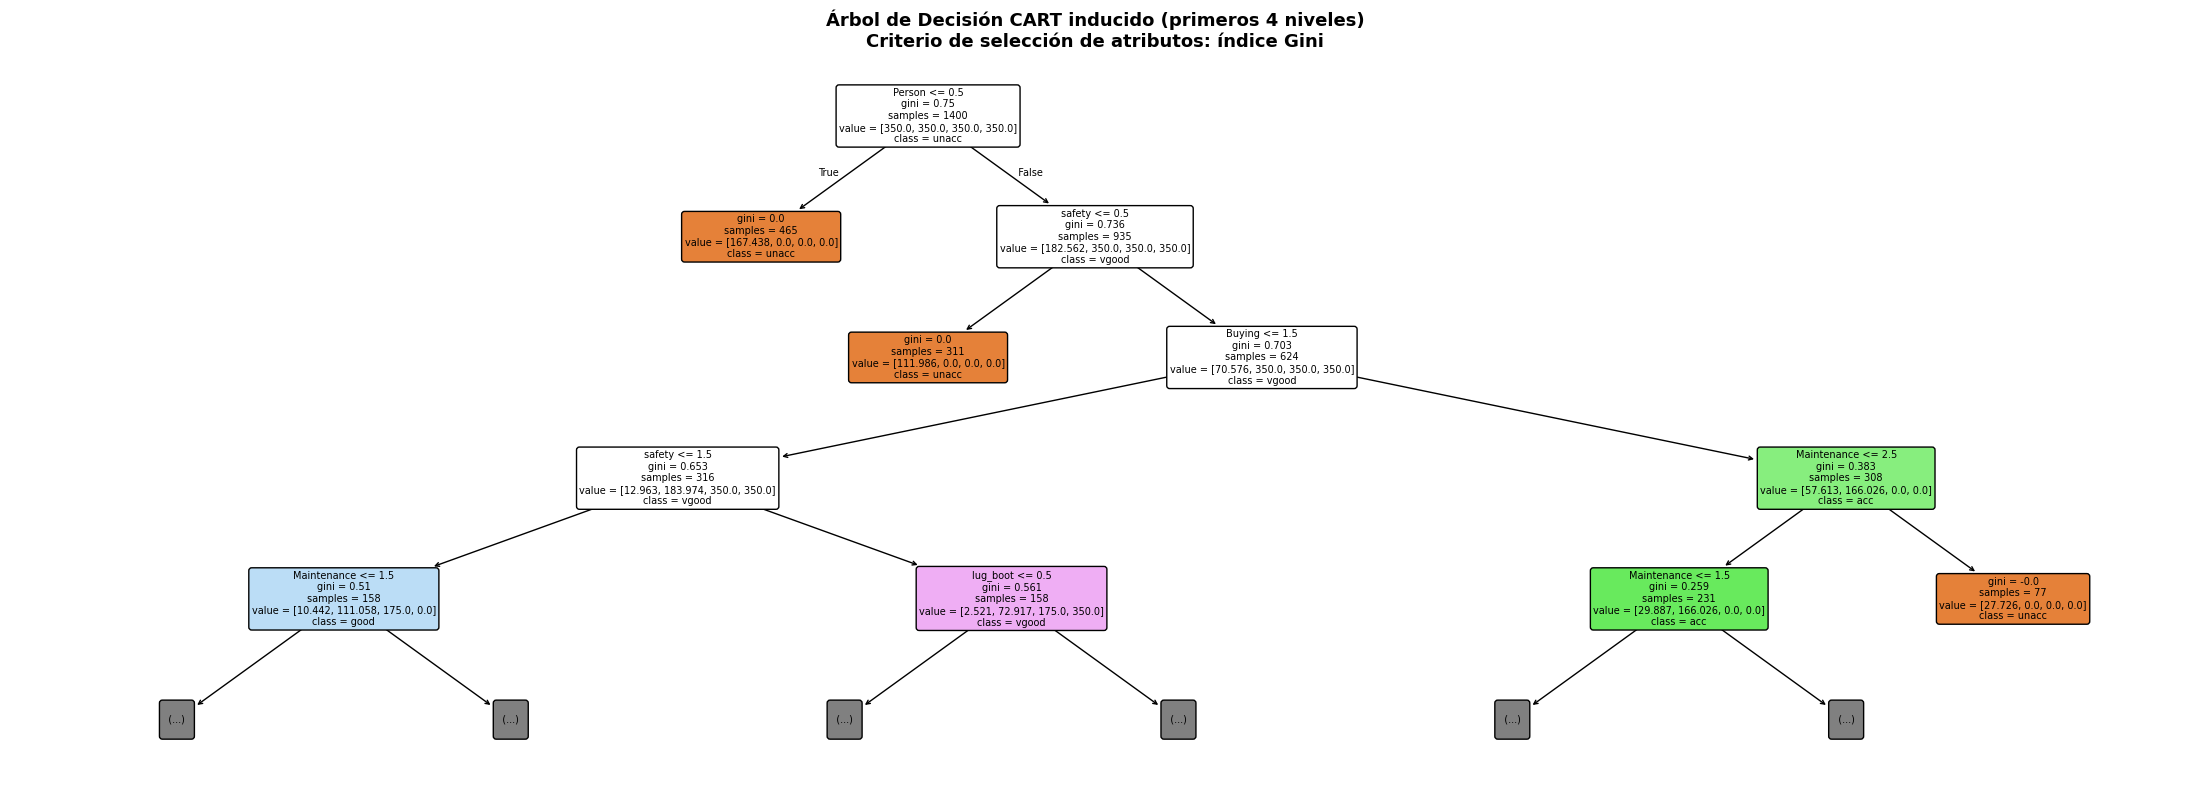

In [70]:
# ─── Visualización del árbol de decisión inducido ────────────────────────────
# El árbol aprendido puede traducirse directamente a reglas de clasificación,
# una de las ventajas explícitas señaladas en el material del curso.
# Se muestran los primeros 4 niveles por legibilidad.

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=4,
    ax=ax
)
ax.set_title(
    'Árbol de Decisión CART inducido (primeros 4 niveles)\n'
    'Criterio de selección de atributos: índice Gini',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig5_arbol_decision.png', dpi=100, bbox_inches='tight')
plt.show()

El árbol muestra únicamente los primeros **4 niveles** por legibilidad, aunque 
el árbol completo alcanza una profundidad de **6 niveles** con **15 nodos hoja**. 
El criterio de selección de atributos en cada nodo es el **índice Gini**.

El **nodo raíz** es `Person <= 0.5`, correspondiente a `Person=2` en la 
codificación ordinal. Esta división separa **465 instancias** con **Gini=0.0**, 
clasificadas directamente como `unacc` sin necesidad de divisiones adicionales. 
Esto confirma el hallazgo del EDA: ningún vehículo con capacidad de 2 personas 
alcanza una clasificación positiva.

Para las instancias con `Person > 0.5`, el árbol aplica `safety <= 0.5` como 
**segunda división**, correspondiente a `safety=low`. Este nodo separa otras 
**311 instancias** también con **Gini=0.0**, igualmente clasificadas como `unacc`. 
A partir del tercer nivel, el árbol introduce `Buying` y `Maintenance` para 
discriminar entre las clases `acc`, `good` y `vgood`, con índices Gini más 
elevados que reflejan la mayor dificultad para separar estas clases entre sí.

La estructura del árbol es directamente interpretable como reglas de 
clasificación condicionales, una de las ventajas explícitamente señaladas 
del algoritmo **CART** en el material del curso. Por ejemplo: *si `Person=2` 
entonces `unacc`; si `Person>2` y `safety=low` entonces `unacc`*.

### 8.4 Importancia de atributos en el Random Forest

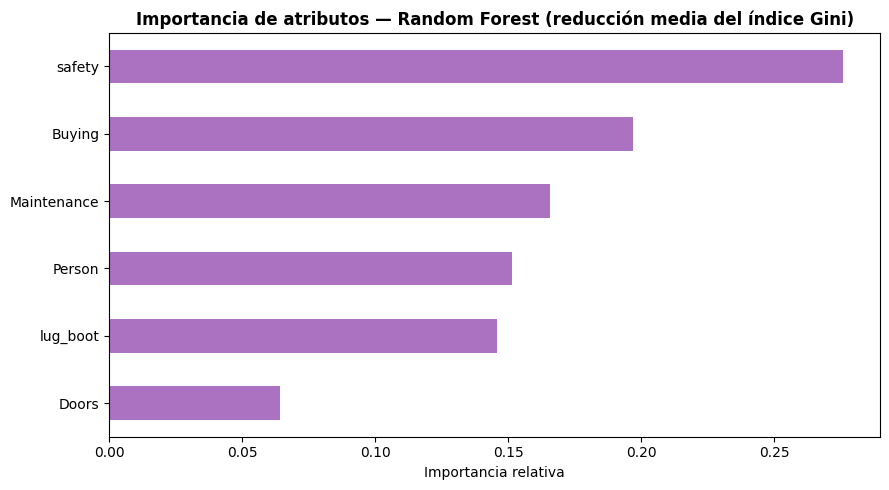

Ranking de atributos por importancia:
safety         0.2759
Buying         0.1970
Maintenance    0.1656
Person         0.1514
lug_boot       0.1458
Doors          0.0643
dtype: float64


In [71]:
# ─── Importancia de atributos en el Random Forest ────────────────────────────
# El Random Forest permite calcular la importancia de cada atributo de entrada
# como la reducción media del índice Gini que aporta en todos los árboles del bosque.
# Esto nos permite verificar empíricamente qué atributos tienen mayor capacidad
# discriminativa, validando las observaciones del EDA.

importancias = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importancias.plot(kind='barh', ax=ax, color='#9b59b6', alpha=0.85)
ax.set_title('Importancia de atributos — Random Forest (reducción media del índice Gini)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig7_importancia_atributos.png', dpi=120, bbox_inches='tight')
plt.show()

print('Ranking de atributos por importancia:')
print(importancias.round(4))

La importancia de atributos se calcula como la **reducción media del índice 
Gini** que cada atributo aporta a lo largo de los 200 árboles del bosque 
(Pedregosa et al., 2011). `safety` es el 
atributo más relevante (**0.28**), seguido de `Buying` (0.20) y `Maintenance` 
(0.17). `Person` ocupa el cuarto lugar (0.15) a pesar de haber sido el **nodo 
raíz** en el árbol **CART** individual, lo que refleja que en el promedio de 200 
árboles su importancia global es menor que la de `safety`. `Doors` es el atributo 
menos relevante (0.06), resultado consistente con el patrón observado en el EDA 
donde no mostraba poder discriminativo entre clases.

### 8.5 Hallazgos de la evaluación

#### Árbol de Decisión (CART)

El árbol de decisión **CART** con profundidad máxima **6** induce un modelo 
interpretable que alcanza una exactitud global del **90.00%** sobre los datos 
de test. El algoritmo seleccionó `Person` como **nodo raíz** y `safety` como 
segunda división, ambos produciendo subgrupos perfectamente puros (**Gini=0.0**) 
clasificados directamente como `unacc`, resultado consistente con lo anticipado 
en el EDA. Esto confirma que `Person` tiene mayor capacidad de reducción de 
impureza global que `safety`, a pesar de que este último presentaba un poder 
discriminativo visualmente más evidente en el análisis exploratorio.

Sin embargo, la profundidad limitada introduce un sesgo que afecta el rendimiento 
en las clases minoritarias. Como indica el material del curso: *«árboles más cortos 
pueden generar más errores en las decisiones»* (Tema 3, *Ideas clave*, UNIR), 
reflejando el dilema entre complejidad del árbol y capacidad de generalización.

#### Random Forest (Bagging)

El **Random Forest** con **200 árboles** en paralelo alcanza una exactitud global 
del **98.57%**, mejorando sustancialmente al árbol individual en todas las métricas. 
La agregación de múltiples hipótesis parciales (cada árbol entrenado sobre un 
subconjunto aleatorio **bootstrap**) reduce la **varianza** del clasificador sin 
incrementar el **bias**, que es precisamente el mecanismo de mejora del aprendizaje 
integrado descrito en el material del curso (Tema 3, *Ideas clave*, UNIR).

El análisis de importancia de atributos revela que `safety` es el predictor más 
relevante del bosque (**0.28**), seguido de `Buying` (0.20) y `Maintenance` (0.17). 
Aunque `Person` fue seleccionado como **nodo raíz** por **CART**, ocupa el cuarto 
lugar en importancia global del **Random Forest** (0.15), lo que refleja que en 
el promedio de 200 árboles su capacidad discriminativa es superada por `safety`. 
`lug_boot` ocupa el quinto lugar (0.15), mientras que `Doors` confirma su baja 
relevancia (**0.06**), resultado consistente con el EDA.

## 9. Comparación del desempeño de modelos

 ### 9.1 Matrices de confusión comparativas  

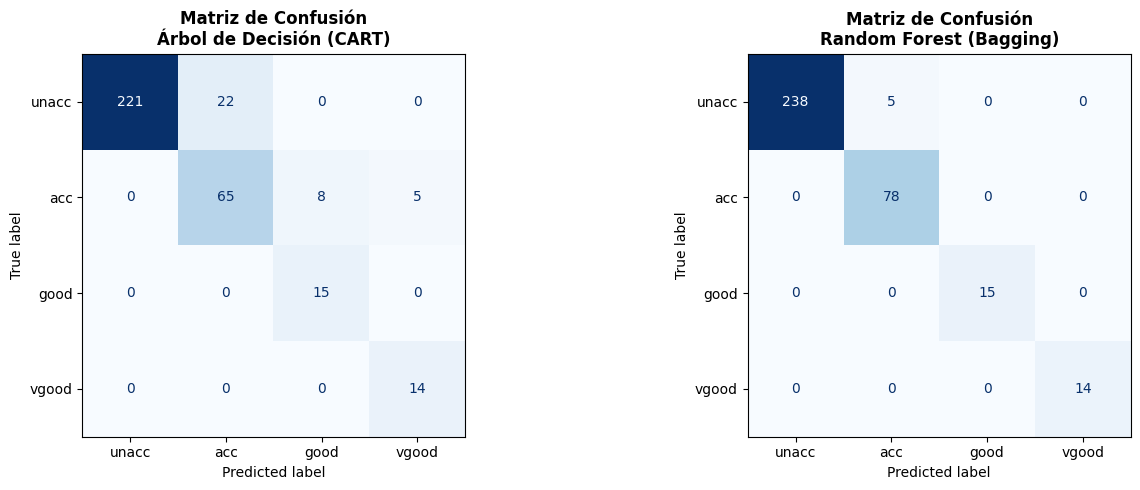

In [72]:
# ─── Matrices de confusión ───────────────────────────────────────────────────
# La matriz de confusión muestra para cada clase cuántas instancias fueron
# clasificadas correctamente (diagonal) e incorrectamente (fuera de la diagonal).
# Es la base para calcular TP, FP, FN y TN de cada clase.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_dt, y_pred_rf],
    ['Árbol de Decisión (CART)', 'Random Forest (Bagging)']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Matriz de Confusión\n{titulo}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_matrices_confusion.png', dpi=120, bbox_inches='tight')
plt.show()



El **Árbol de Decisión CART** clasifica correctamente **315** de **350** 
instancias, con sus **35 errores** distribuidos en tres celdas fuera de la 
diagonal: 22 instancias de `unacc` clasificadas como `acc`, 8 de `acc` 
clasificadas como `good` y 5 de `acc` clasificadas como `vgood`. Las clases 
`good` y `vgood` no generan ningún error en sus filas, aunque a costa de 
introducir **falsos positivos** en las predicciones de estas clases.

El **Random Forest** reduce los errores a **5**, todos concentrados en 
una única celda (`unacc`→`acc`), eliminando completamente los falsos positivos 
en `good` y `vgood` que presentaba el modelo de **Árbol de Decisión CART**. 
Las clases `acc`, `good` y `vgood` alcanzan clasificación perfecta en sus filas.

Ambos modelos fallan exclusivamente en **sentido ascendente**: todos los errores 
se ubican a la derecha de la diagonal, lo que significa que siempre sobreestiman 
la aceptabilidad del vehículo, nunca la subestiman. En un contexto real, este 
patrón es más **perjudicial** que el caso contrario, ya que implicaría recomendar 
un vehículo inaceptable como aceptable. El modelo **Random Forest** minimiza 
este riesgo de forma significativa frente al modelo de **Árbol de Decisión CART**.

### 9.2 Umbrales de clasificación 

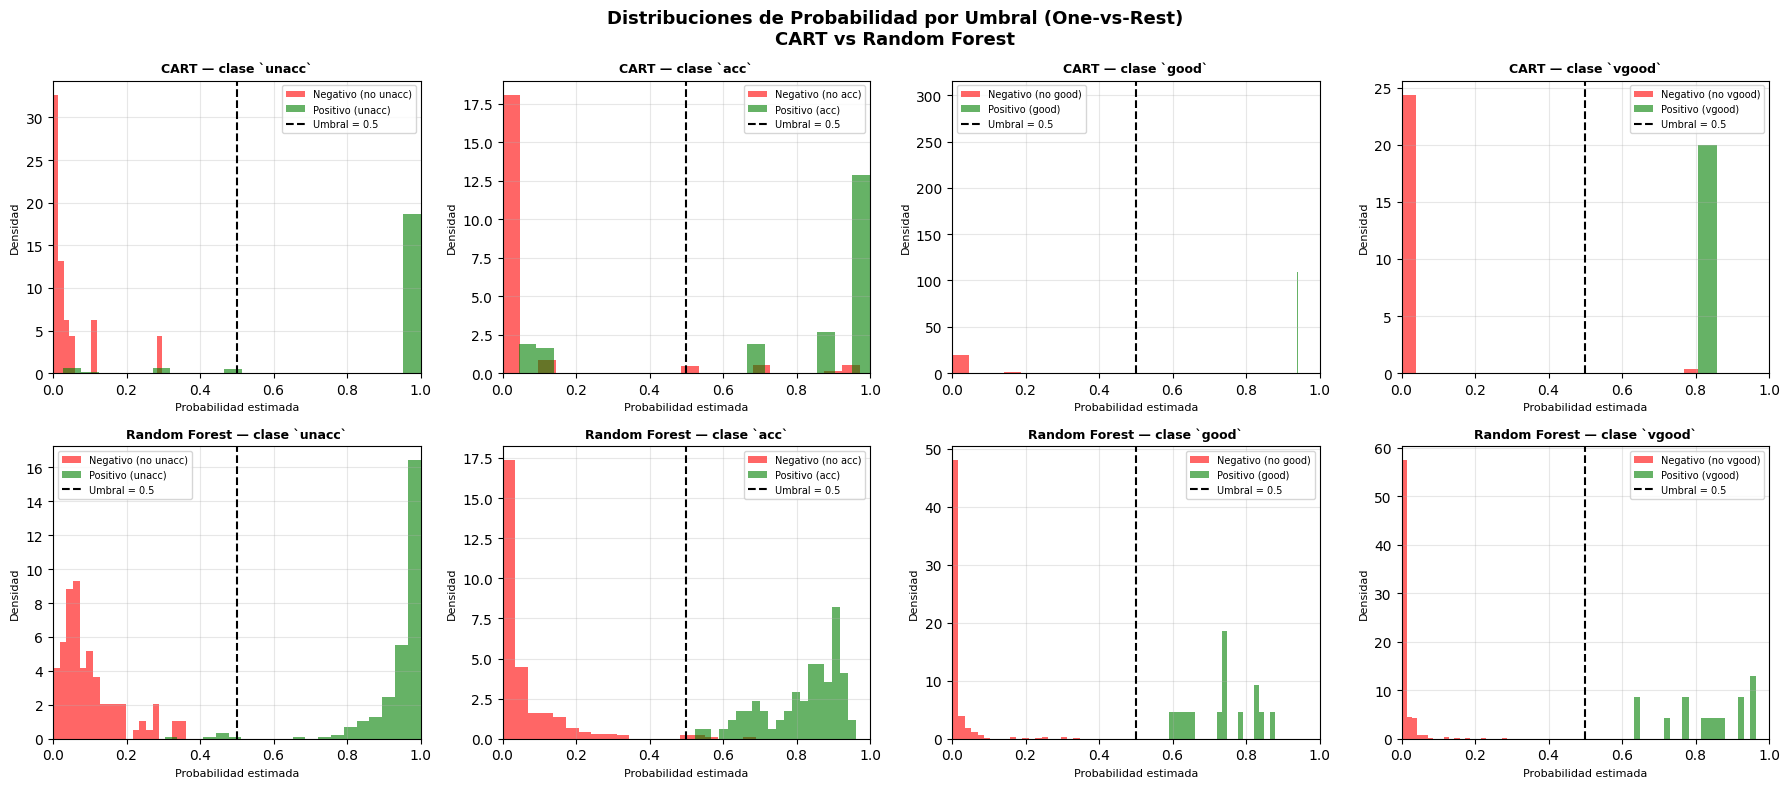

In [73]:
# ─── Análisis de Umbrales: distribuciones de probabilidad estimada ───────────
# Para cada clase (one-vs-rest) y cada modelo, se visualiza cómo distribuye
# las probabilidades estimadas entre instancias positivas (pertenecen a esa clase)
# e instancias negativas (no pertenecen). Un buen modelo separa claramente ambas
# distribuciones: la positiva concentrada cerca de 1, la negativa cerca de 0.
# El umbral de decisión estándar es 0.5 (línea discontinua).

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribuciones de Probabilidad por Umbral (One-vs-Rest)\nCART vs Random Forest',
             fontsize=13, fontweight='bold')

# Binarizar etiquetas reales para comparar contra probabilidades estimadas
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
modelos    = [('CART', dt), ('Random Forest', rf)]

for row, (nombre, modelo) in enumerate(modelos):
    # Obtener probabilidades estimadas para cada clase (shape: n_instancias × n_clases)
    y_prob = modelo.predict_proba(X_test)

    for col, clase in enumerate(nombres_clases):
        ax          = axes[row, col]
        probs_clase = y_prob[:, col]       # probabilidades estimadas para esta clase
        y_bin_clase = y_test_bin[:, col]   # etiquetas binarias reales (1=positivo, 0=negativo)

        # Separar probabilidades según si la instancia es positiva o negativa
        probs_pos = probs_clase[y_bin_clase == 1]  # instancias que SI pertenecen a esta clase
        probs_neg = probs_clase[y_bin_clase == 0]  # instancias que NO pertenecen a esta clase

        # density=True normaliza el histograma como distribución de probabilidad
        # para hacer comparables clases con distinto número de instancias
        ax.hist(probs_neg, bins=20, alpha=0.6, color='red',
                label=f'Negativo (no {clase})', density=True)
        ax.hist(probs_pos, bins=20, alpha=0.6, color='green',
                label=f'Positivo ({clase})',    density=True)

        # Umbral de decisión estándar: predict() asigna la clase con mayor probabilidad
        ax.axvline(x=0.5, color='black', linestyle='--',
                   linewidth=1.5, label='Umbral = 0.5')

        ax.set_title(f'{nombre} — clase `{clase}`', fontsize=9, fontweight='bold')
        ax.set_xlabel('Probabilidad estimada', fontsize=8)
        ax.set_ylabel('Densidad',              fontsize=8)
        ax.set_xlim([0, 1])
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_umbrales.png', dpi=120, bbox_inches='tight')
plt.show()


Las gráficas muestran la distribución de probabilidades estimadas para las 
instancias positivas (verde) y negativas (rojo) de cada clase, con el umbral 
por defecto de **0.5** marcado con línea discontinua.

**CART** muestra una separación clara en las clases `unacc` y `vgood`: las 
instancias negativas (rojo) se concentran cerca de **0.0** y las positivas 
(verde) cerca de **1.0**, con solapamiento mínimo en torno al umbral. Sin 
embargo, la clase `acc` presenta el mayor solapamiento entre distribuciones: 
ambas clases tienen masa en el rango **0.0–0.2**, lo que explica los **13 
errores** de `acc` observados en la matriz de confusión.

**Random Forest** exhibe una separación más limpia en todas las clases. Las 
distribuciones negativas (rojo) se concentran fuertemente cerca de **0.0**, 
mientras que las positivas (verde) se desplazan hacia valores altos, reduciendo 
el solapamiento respecto a **CART**. La clase `acc` sigue siendo la más difícil 
de separar, pero con menor masa en la zona de solapamiento que en **CART**.

En ambos modelos, el umbral por defecto de **0.5** es apropiado para las clases 
`good` y `vgood`, donde no existe solapamiento visible entre distribuciones. 
Para la clase `acc`, elevar el umbral a **0.6–0.7** reduciría los **falsos 
positivos** observados en **CART**, aunque en **Random Forest** el solapamiento 
es ya suficientemente pequeño como para que el impacto sea marginal.

### 9.3 Curvas ROC comparativas CART vs Random Forest

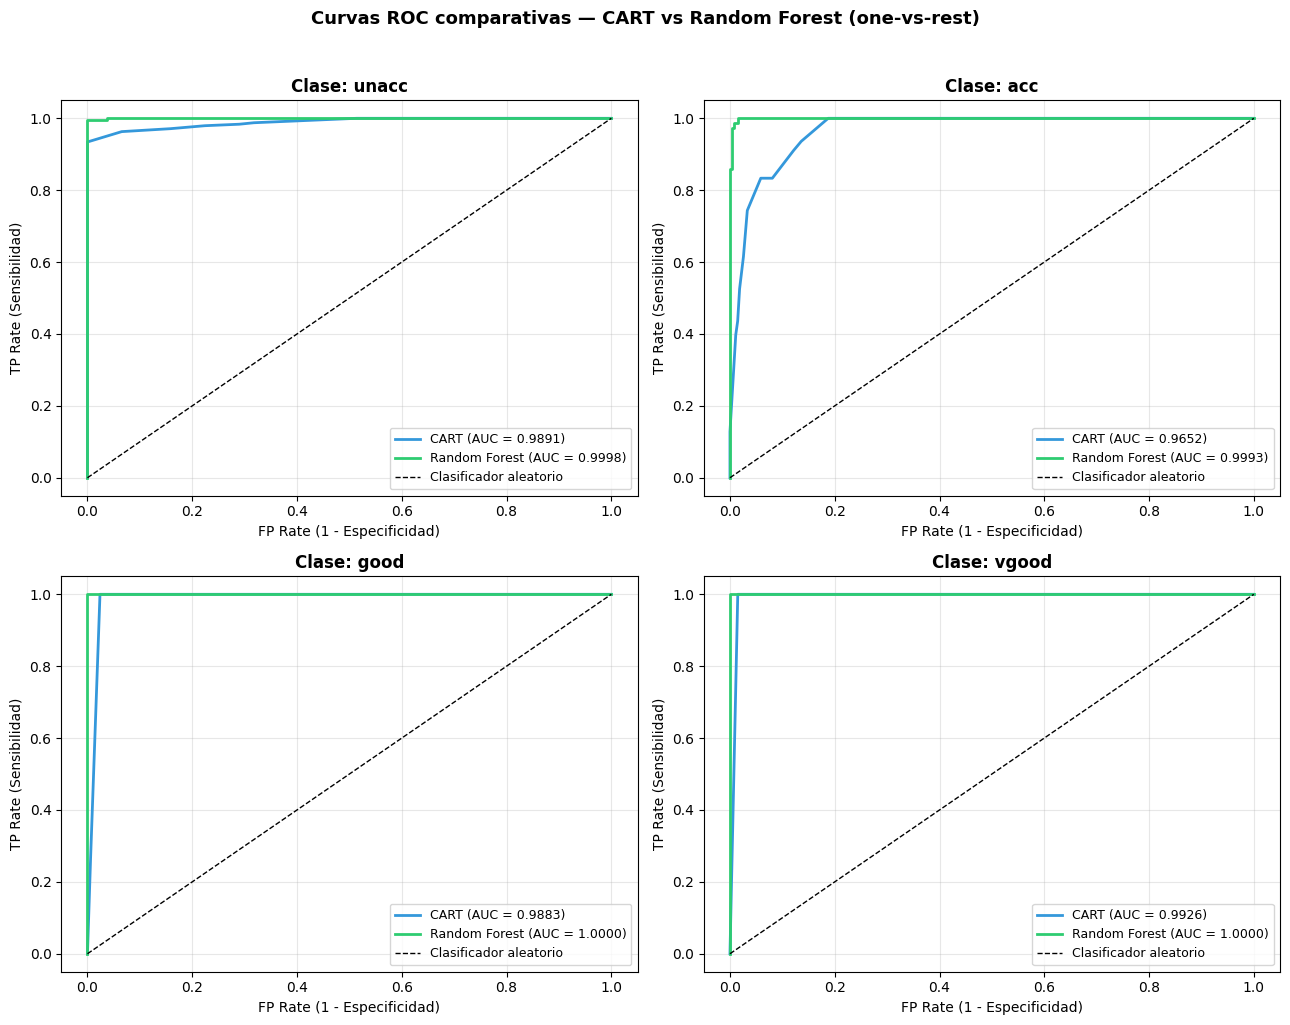

=== AUC por clase ===
Clase            CART   Random Forest
-------------------------------------
unacc          0.9891          0.9998
acc            0.9652          0.9993
good           0.9883          1.0000
vgood          0.9926          1.0000


In [74]:
# ─── Curvas ROC comparativas CART vs Random Forest ───────────────────────────
# Se representan las curvas ROC de ambos modelos en una misma gráfica por clase
# para comparar directamente su capacidad discriminativa.
# El área bajo la curva (AUC) toma valores entre 0.5 (clasificador aleatorio)
# y 1.0 (clasificación perfecta), tal como indica el material del Tema 3.
# Estrategia one-vs-rest: cada clase se evalúa como positiva frente al resto.

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas reales para one-vs-rest (shape: n_instancias × n_clases)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# Obtener probabilidades estimadas de ambos modelos
y_prob_dt = dt.predict_proba(X_test)
y_prob_rf = rf.predict_proba(X_test)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, clase in enumerate(orden_clases):
    # roc_curve devuelve: FP Rate (eje X), TP Rate (eje Y), umbrales
    fpr_dt, tpr_dt, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])

    # auc() calcula el área bajo la curva ROC (integración trapezoidal)
    auc_dt = auc(fpr_dt, tpr_dt)
    auc_rf = auc(fpr_rf, tpr_rf)

    axes[i].plot(fpr_dt, tpr_dt, color='#3498db', lw=2,
                 label=f'CART (AUC = {auc_dt:.4f})')
    axes[i].plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2,
                 label=f'Random Forest (AUC = {auc_rf:.4f})')
    # Línea diagonal = clasificador aleatorio (AUC = 0.5), referencia base
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
    axes[i].set_title(f'Clase: {clase}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('FP Rate (1 - Especificidad)')
    axes[i].set_ylabel('TP Rate (Sensibilidad)')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Curvas ROC comparativas — CART vs Random Forest (one-vs-rest)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_roc.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen AUC por clase
print('=== AUC por clase ===')
print(f'{"Clase":10s} {"CART":>10s} {"Random Forest":>15s}')
print('-' * 37)
for i, clase in enumerate(orden_clases):
    # auc(*roc_curve(...)[:2]) desempaqueta fpr y tpr directamente en auc()
    auc_dt = auc(*roc_curve(y_test_bin[:, i], y_prob_dt[:, i])[:2])
    auc_rf = auc(*roc_curve(y_test_bin[:, i], y_prob_rf[:, i])[:2])
    print(f'{clase:10s} {auc_dt:>10.4f} {auc_rf:>15.4f}')


Las curvas ROC se calcularon mediante la estrategia **one-vs-rest**: dado que el 
problema tiene 4 clases, se generó una curva independiente por clase tratando cada 
una como positiva frente al resto. El **Área Bajo la Curva (AUC)** toma valores entre 0.5 (clasificador aleatorio) 
y 1.0 (clasificación perfecta), tal como se describe en el material del curso 
(Tema 3, *Ideas clave*, UNIR).

**Random Forest** supera a **CART** en todas las clases. La diferencia más 
pronunciada se observa en `acc` (**0.9652** vs **0.9993**), que es precisamente 
la segunda clase más frecuente del dataset y donde CART mostraba mayor dificultad 
en las métricas anteriores. Para las clases `good` y `vgood`, Random Forest 
alcanza un **AUC = 1.0000**, confirmando una capacidad discriminativa perfecta. 
CART, aunque con valores altos en todas las clases (mínimo 0.9652), muestra una 
curva visualmente menos pronunciada en `acc`, lo que refleja una mayor dificultad 
para separar esta clase del resto a diferentes umbrales de clasificación.

Ambos modelos superan ampliamente al **clasificador aleatorio** (diagonal 
punteada) en todas las clases, confirmando que ninguno de los dos clasifica 
por azar.

### 9.4 Tabla comparativa de metricas de desempeño

In [75]:
# ─── Tabla comparativa de metricas de desempeno ──────────────────────────────
# Se incluyen las metricas solicitadas en el enunciado mas el F1-score (media armonica
# de precision y recall) y los resultados de validacion cruzada para estimar
# la precision de generalizacion sobre datos futuros no vistos.

def resumen_metricas(nombre, modelo, X_test, y_test, cv_scores):
    y_pred = modelo.predict(X_test)
    return {
        'Modelo'                  : nombre,
        'Accuracy (test)'         : round(accuracy_score(y_test, y_pred), 4),
        'Precision macro (test)'  : round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'TP Rate/Recall macro'    : round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'F1-Score macro (test)'   : round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'CV 10-fold (media)'      : round(cv_scores.mean(), 4),
        'CV 10-fold (desv.tipica)': round(cv_scores.std(), 4),
    }

tabla = pd.DataFrame([
    resumen_metricas('Arbol de Decision (CART)', dt, X_test, y_test, cv_scores_dt),
    resumen_metricas('Random Forest (Bagging)',  rf, X_test, y_test, cv_scores_rf),
]).set_index('Modelo')

print('=== Comparativa de metricas de desempeno ===')
display(tabla)

=== Comparativa de metricas de desempeno ===


,Accuracy (test),Precision macro (test),TP Rate/Recall macro,F1-Score macro (test),CV 10-fold (media),CV 10-fold (desv.tipica)
Modelo,,,,,,
Arbol de Decision (CART),0.9000,0.7840,0.9357,0.8446,0.9006,0.0299
Random Forest (Bagging),0.9857,0.9849,0.9949,0.9896,0.9789,0.0138


**Random Forest** supera a **CART** en todas las métricas evaluadas. La diferencia 
más pronunciada se observa en la **Precisión macro** (0.7840 vs 0.9849), lo que 
confirma que CART genera falsos positivos en las clases minoritarias con mayor 
frecuencia que Random Forest. El **F1-Score macro** (0.8446 vs 0.9896) refleja 
este mismo desequilibrio al combinar precisión y recall en una sola métrica.

El **TP Rate macro** de CART (0.9357) es relativamente alto a pesar de su menor 
exactitud global, lo que indica que el modelo detecta bien las instancias de cada 
clase pero a costa de introducir falsos positivos. Random Forest mantiene ambas 
métricas por encima de **0.98**, logrando un clasificador equilibrado sin ese 
compromiso.

La **validación cruzada 10-fold** confirma la superioridad en generalización: 
Random Forest obtiene una media de **0.9789** con una desviación de tan solo 
**±0.0138**, frente al **0.9006 ± 0.0299** de CART. La menor desviación típica 
de Random Forest indica que su rendimiento es más **estable y consistente** 
ante diferentes particiones de los datos, independientemente de cómo se divida 
el dataset.

### 9.5 Grafica comparativa de metricas

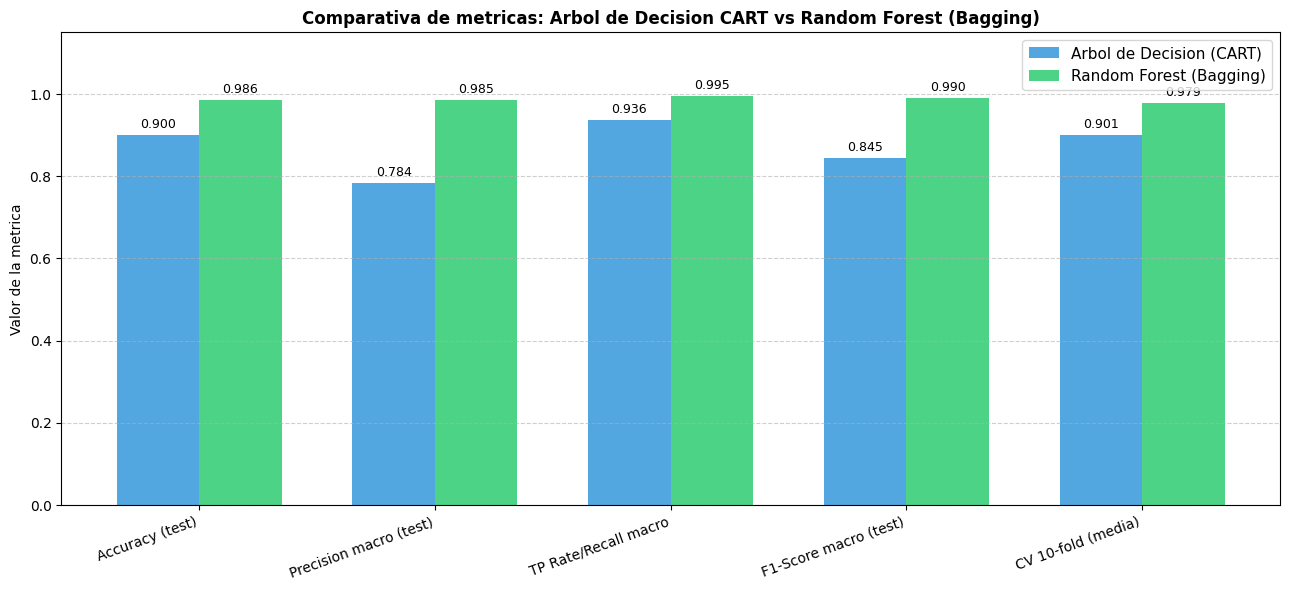

In [76]:
# ─── Grafica comparativa de metricas ─────────────────────────────────────────
# Representacion visual superpuesta de las metricas de ambos modelos,
# tal como se indica en el enunciado: de forma grafica y comparada/superpuesta.

metricas_nombres = ['Accuracy (test)', 'Precision macro (test)',
                    'TP Rate/Recall macro', 'F1-Score macro (test)', 'CV 10-fold (media)']
x = np.arange(len(metricas_nombres))
ancho = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - ancho/2, tabla.loc['Arbol de Decision (CART)', metricas_nombres],
               ancho, label='Arbol de Decision (CART)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + ancho/2, tabla.loc['Random Forest (Bagging)',  metricas_nombres],
               ancho, label='Random Forest (Bagging)',  color='#2ecc71', alpha=0.85)

ax.set_ylabel('Valor de la metrica')
ax.set_title('Comparativa de metricas: Arbol de Decision CART vs Random Forest (Bagging)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig6_comparativa_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

La representación visual confirma la superioridad de **Random Forest** en todas 
las métricas. El contraste más notable es la **Precisión macro**: **CART** obtiene 
0.784 frente al 0.985 de **Random Forest**, siendo la mayor brecha entre ambos 
modelos. Esto refleja que CART, a pesar de detectar bien las instancias de cada 
clase (**TP Rate macro = 0.936**), clasifica con mayor frecuencia instancias como 
`good` o `vgood` que en realidad no lo son. **Random Forest** mantiene ambas 
métricas por encima de **0.98**, logrando un clasificador equilibrado sin ese 
compromiso entre precisión y recall.

### 9.6 Hallazgos de la comparativa

**Random Forest** supera a **CART** en todas las métricas evaluadas. La diferencia 
más pronunciada se observa en la **Precisión macro** (0.784 vs 0.985) y el 
**F1-Score macro** (0.845 vs 0.990), que ponderan por igual todas las clases 
independientemente de su frecuencia. Esto confirma lo descrito en el material del 
curso (Tema 3, *Ideas clave*, UNIR): en los métodos **Bagging**, cada algoritmo 
se entrena con un subconjunto aleatorio de datos extraídos del mismo conjunto de 
entrenamiento y las salidas se promedian para obtener el resultado final, reduciendo 
la sensibilidad del modelo a los datos de entrenamiento y mejorando su generalización.

Las **matrices de confusión comparativas** revelan que ambos modelos cometen errores 
exclusivamente en **sentido ascendente**: sobreestiman la aceptabilidad del vehículo, 
nunca la subestiman. **CART** comete **35 errores** distribuidos en tres celdas fuera 
de la diagonal, mientras que **Random Forest** los reduce a **5**, todos concentrados 
en la celda `unacc` → `acc`. En un contexto real, este patrón de error es más 
perjudicial que el caso contrario, ya que implica recomendar vehículos inaceptables 
como aceptables.

El análisis de **umbrales** muestra que `acc` es la clase con mayor solapamiento 
entre distribuciones de probabilidad en ambos modelos, lo que explica que sea la 
única clase donde persisten errores. Para **CART**, elevar el umbral de decisión 
a **0.6–0.7** en esta clase reduciría los **falsos positivos**, mientras que en 
**Random Forest** el solapamiento es suficientemente pequeño como para que el 
impacto sea marginal. Las clases `good` y `vgood` presentan separación casi perfecta 
en ambos modelos, confirmando que el umbral por defecto de **0.5** es apropiado 
para estas clases.

Las **curvas ROC** cuantifican este comportamiento a todos los umbrales posibles: 
**Random Forest** supera a **CART** en todas las clases, con la diferencia más 
significativa en `acc` (AUC: 0.9652 vs 0.9993). **Random Forest** alcanza 
**AUC=1.0000** en `good` y `vgood`, confirmando separación perfecta entre 
instancias positivas y negativas. La **validación cruzada 10-fold** refuerza 
esta superioridad: **Random Forest** obtiene **0.9789 ± 0.0138** frente al 
**0.9006 ± 0.0299** de **CART**, con menor desviación típica que indica mayor 
estabilidad ante diferentes particiones de los datos.

## 10. Discusión de resultados y propuestas de mejora

### Ventajas y desventajas de cada modelo

**Árbol de Decisión (CART):**
Como señala el material del curso (Tema 3, *Ideas clave*, UNIR), los árboles de 
decisión presentan como ventajas principales su **facilidad de interpretación** y 
la posibilidad de traducirlos directamente a **reglas de clasificación** condicionales 
legibles. No requieren conocimiento previo del dominio ni normalización de los datos. 
En este problema, el árbol de profundidad **6** produce reglas lógicas directamente 
legibles sobre la aceptabilidad de los vehículos, como se aprecia en la visualización 
del árbol inducido.

Sin embargo, su principal limitación es la tendencia al **sobreajuste**: sin 
restricción de profundidad, **CART** seguiría dividiendo nodos indefinidamente, 
reduciendo el error de entrenamiento sin garantizar buena generalización en nuevas 
instancias. El parámetro `max_depth=6` mitiga este problema mediante **poda preventiva** 
(*pre-pruning*), aunque introduce un sesgo que afecta la precisión en las clases 
minoritarias `good` y `vgood`. Como indica el material del curso: *«árboles más 
cortos pueden generar más errores en las decisiones»* (Tema 3, *Ideas clave*, UNIR), 
reflejando el dilema entre complejidad del árbol y capacidad de generalización.

**Random Forest (Bagging):**
**Random Forest** resuelve el problema del sobreajuste del árbol individual mediante 
la construcción de **200 hipótesis parciales**, cada una entrenada sobre un 
subconjunto **bootstrap** aleatorio de los datos. La predicción final agrega las 
predicciones de todos los árboles mediante votación, reduciendo la **varianza** 
sin incrementar el **bias**. El resultado es un modelo con mejor generalización en 
todas las clases, incluyendo las minoritarias, a un coste computacional moderado. 
Su principal desventaja es la **pérdida de interpretabilidad**: a diferencia del 
árbol individual, **Random Forest** no produce reglas de clasificación legibles, 
lo que dificulta su auditoría en contextos que requieren explicabilidad.

### Propuestas de mejora

1. **Optimización de hiperparámetros:** aplicar `GridSearchCV` con validación 
cruzada estratificada para optimizar `max_depth` y `min_samples_split` en **CART** 
y `n_estimators` y `max_features` en **Random Forest**, reduciendo el sesgo de la 
configuración manual.

2. **Tratamiento explícito del desbalance de clases:** técnicas de sobremuestreo 
como **SMOTE** (Chawla et al., 2002) sobre las clases `good` y `vgood` podrían mejorar la precisión en 
estas clases sin depender únicamente del ajuste de pesos con `class_weight`.

3. **Métodos de Boosting:** algoritmos como **AdaBoost** o **XGBoost** entrenan 
árboles de forma secuencial priorizando las instancias peor clasificadas en cada 
iteración. Como indica el material del curso, *«la principal ventaja de este tipo 
de algoritmos es que son muy precisos cuando se aplican como métodos de 
clasificación»* (Tema 3, *Ideas clave*, UNIR).

4. **Poda posterior (C4.5):** aplicar el algoritmo de poda pesimista de **C4.5** (Quinlan, 1993)
al árbol inducido por **CART** podría mejorar su capacidad de generalización sin 
necesidad de limitar su profundidad a priori, siguiendo el procedimiento descrito 
en el Tema 3 del material del curso.

## Referencias

• Bohanec, M. (1997). *Car Evaluation* [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/19/car+evaluation

• Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

• Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830. https://scikit-learn.org/stable

• Quinlan, J. R. (1993). *C4.5: Programs for machine learning*. Morgan Kaufmann.

• UNIR. (2024). *Técnicas de inteligencia artificial: Ideas clave, Temas 1 y 3*. Universidad Internacional de La Rioja.